# Joja — Ce que 3,4 millions de paniers disent de l'habitude

**T-DAT-600 · Analyse exploratoire et modèle prédictif**

---

## Résumé

Ce projet analyse **3,4 millions de commandes** passées par **206 209 clients** d'un
service de livraison de courses, soit **32,4 millions de lignes de produits**.

L'analyse converge vers un constat unique : **cette activité ne vend pas des produits,
elle vend une habitude**. 59 % des articles commandés sont des rachats, et cette part
grimpe à 80 % chez les clients anciens. Le panier, lui, ne grossit jamais — il reste
à dix articles du premier au soixantième achat. Autrement dit, la croissance ne viendra
pas d'un panier plus gros, mais d'une habitude installée plus vite et plus large.

Nous en tirons huit leviers d'action, puis un **modèle prédictif** qui anticipe le
contenu de la prochaine commande d'un client (ROC-AUC 0,830).

## Objectifs

1. **Profiler et nettoyer** les cinq jeux de données, puis les fusionner en une table unique.
2. **Identifier des tendances exploitables**, au-delà des statistiques descriptives.
3. **Traduire chaque constat en action** pour un décideur non technique.
4. **Construire et évaluer un modèle** de prédiction de réachat.

## Comment lire ce document

Chaque section suit le même déroulé : la **question** posée, la **méthode** employée,
le **constat** chiffré, puis l'**action** recommandée. Les encadrés « Pour le décideur »
résument sans jargon ; les blocs de code et les notes méthodologiques s'adressent au
lecteur technique. On peut lire uniquement les encadrés et suivre l'argumentaire.

**Exécution :** menu *Run → Restart Kernel and Run All Cells*. Compter environ trois
minutes et 1,5 Go de mémoire vive. Les données doivent se trouver dans `data/`.

## 0. Outils, et pourquoi ceux-là

**pandas** porte toute la manipulation. Le format CSV est tabulaire et le modèle
*DataFrame* lui correspond exactement ; les opérations de regroupement et de jointure
dont nous avons besoin y sont natives et vectorisées, donc exécutées en C plutôt qu'en
boucles Python. Une alternative comme *Polars* serait plus rapide, mais pandas reste le
standard de fait, ce qui prime pour un travail destiné à être relu.

**NumPy** fournit les tableaux typés sur lesquels pandas s'appuie. Nous l'utilisons
directement pour le calcul vectorisé et le tirage aléatoire reproductible.

**Matplotlib** trace les graphiques. Seaborn produirait des rendus plus flatteurs en
moins de lignes, et Plotly ajouterait l'interactivité, mais Matplotlib donne le contrôle
explicite sur chaque élément — indispensable quand on doit justifier chaque choix visuel
et retirer tout ornement superflu.

**scikit-learn** couvre la partie prédictive : découpe des données, modèles, métriques
et importance des variables partagent une interface unique (`fit` / `predict`), ce qui
rend la comparaison entre modèles immédiate.

Toutes ces bibliothèques sont figées dans `requirements.txt`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

DATA = Path("data")
ALEA = 42                      # graine unique : tout le notebook est reproductible

# Charte graphique sobre : pas de grille lourde, pas de cadre inutile.
# Chaque element retire est de l encre qui n informait pas (Tufte).
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "figure.autolayout": True,
})
ENCRE, ACCENT, ALERTE = "#2F4858", "#00798C", "#D1495B"

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.5.2


## 1. Profilage des données brutes

**Question.** Que contiennent réellement ces cinq fichiers, et peut-on leur faire confiance ?

**Méthode.** On charge chaque table en imposant des types compacts, puis on mesure
systématiquement : dimensions, types, valeurs absentes, doublons, occupation mémoire.

Le choix des types n'est pas cosmétique. Par défaut pandas attribue `int64` à tout
entier, soit huit octets par valeur. Or un `product_id` ne dépasse pas 50 000 et tient
sur un `int32`, un jour de semaine sur un `int8`. Sur 32 millions de lignes, l'écart
se compte en gigaoctets — et conditionne la faisabilité du projet sur une machine
ordinaire.

In [2]:
# Types imposes : voir la note ci-dessus. Le gain est mesure en section 2.
TYPES = {
    "order_products": {"order_id":"int32","product_id":"int32",
                       "add_to_cart_order":"int16","reordered":"int8"},
    "orders": {"order_id":"int32","user_id":"int32","order_number":"int16",
               "order_dow":"int8","order_hour_of_day":"int8",
               "days_since_prior_order":"float32"},
    "products": {"product_id":"int32","aisle_id":"int16","department_id":"int8"},
    "aisles": {"aisle_id":"int16"},
    "departments": {"department_id":"int8"},
}

brut = {n: pd.read_csv(DATA / f"{n}.csv", dtype=t) for n, t in TYPES.items()}

profil = pd.DataFrame([{
    "table": n,
    "lignes": len(t),
    "colonnes": t.shape[1],
    "memoire_Mo": round(t.memory_usage(deep=True).sum() / 1024**2, 1),
    "cellules_vides": int(t.isna().sum().sum()),
    "lignes_dupliquees": int(t.duplicated().sum()),
} for n, t in brut.items()]).set_index("table")

profil

,lignes,colonnes,memoire_Mo,cellules_vides,lignes_dupliquees
table,,,,,
order_products,32434489,4,340.3,0,0
orders,3421083,6,52.2,206209,0
products,49688,4,4.1,0,0
aisles,134,2,0.0,0,0
departments,21,2,0.0,0,0


In [3]:
# Ou se trouvent exactement les valeurs absentes ?
for nom, t in brut.items():
    manques = t.isna().sum()
    manques = manques[manques > 0]
    if len(manques):
        print(f"{nom} :", dict(manques))

orders : {'days_since_prior_order': np.int64(206209)}


### Constat 1 — les deux seules anomalies sont structurelles

Le jeu est d'une propreté inhabituelle : **aucun doublon**, et une seule colonne trouée.
Mais les deux irrégularités que l'on trouve portent le **même nombre**, 206 209, qui est
exactement le nombre de clients. Ce n'est pas une coïncidence.

In [4]:
n_clients = brut["orders"].user_id.nunique()
n_vides   = int(brut["orders"].days_since_prior_order.isna().sum())

# Combien de commandes ne figurent dans AUCUNE ligne de produits ?
ids_documentes = set(brut["order_products"].order_id.unique())
orphelines = brut["orders"][~brut["orders"].order_id.isin(ids_documentes)]

# Ces commandes orphelines sont-elles la derniere de leur client ?
rang_max = brut["orders"].groupby("user_id")["order_number"].transform("max")
part_derniere = (orphelines.order_number == rang_max.loc[orphelines.index]).mean()

print(f"clients                               : {n_clients:,}")
print(f"valeurs manquantes days_since_prior   : {n_vides:,}")
print(f"commandes sans aucun produit          : {len(orphelines):,}")
print(f"  ... dont derniere commande du client: {part_derniere*100:.1f} %")

clients                               : 206,209
valeurs manquantes days_since_prior   : 206,209
commandes sans aucun produit          : 206,209
  ... dont derniere commande du client: 100.0 %


Les deux « anomalies » s'expliquent d'elles-mêmes.

**`days_since_prior_order` est vide 206 209 fois** parce qu'une *première* commande n'a
pas de commande précédente. L'absence n'est pas une donnée perdue, c'est une information :
elle identifie l'entrée d'un client dans le service. **La combler serait la détruire.**

**206 209 commandes ne contiennent aucun produit**, et il s'agit à 100 % de la *dernière*
commande de chaque client. Ce jeu de données est celui d'une ancienne compétition
Instacart, dont la dernière commande servait d'épreuve et a été retirée. Conséquence
directe : toute analyse portant sur le contenu des paniers doit **exclure ces commandes**,
faute de quoi elle comptera 206 209 paniers vides. C'est aussi ce qui dictera la
construction de la cible du modèle en section 4.

> **Pour le décideur.** Les données sont saines. Deux particularités demandent
> simplement d'être connues : les premières commandes n'ont pas d'historique, et la
> toute dernière commande de chaque client n'est pas documentée. Aucune ne remet en
> cause les résultats qui suivent.

### Constat 2 — une variable plafonnée, à ne pas prendre au premier degré

In [5]:
v = brut["orders"]["days_since_prior_order"].value_counts().sort_index()
print("Repartition autour du plafond :")
print(v.loc[26:30].to_string())
print(f"\nmaximum observe : {brut['orders'].days_since_prior_order.max():.0f} jours")
print(f"part des commandes exactement a 30 j : "
      f"{(brut['orders'].days_since_prior_order == 30).mean()*100:.1f} %")

Repartition autour du plafond :
days_since_prior_order
26.0     19016
27.0     22013
28.0     26777
29.0     19191
30.0    369323

maximum observe : 30 jours
part des commandes exactement a 30 j : 10.8 %


La valeur 30 concentre **369 323 commandes**, soit dix-huit fois plus que la valeur 29,
et aucune observation ne dépasse 30. Le délai n'est donc pas mesuré au-delà d'un mois :
il est **censuré**. « 30 jours » signifie en réalité « trente jours *ou plus* ».

Toute moyenne calculée sur cette colonne sous-estime donc le délai réel, et un client
absent depuis six mois y est indiscernable d'un client absent depuis un mois. Nous
utiliserons la **médiane** plutôt que la moyenne, et nous nous garderons de conclure
sur le décrochage client à partir de cette variable seule.

*C'est exactement le type de piège que le quartet d'Anscombe illustrait lors du
bootstrap : une statistique juste, calculée sur une variable mal comprise, produit une
conclusion fausse.*

## 2. Nettoyage et fusion en une table unique

**Question.** Comment passer de cinq fichiers à un objet unique exploitable ?

**Méthode.** Ces fichiers ne sont pas des morceaux d'un même tout — les empiler n'aurait
aucun sens. Ce sont **cinq tables reliées par des clés**, à la manière d'une base de
données : `order_products` référence `orders` et `products`, qui référence lui-même
`aisles` et `departments`. On les **joint** donc, avec `merge`.

Deux précautions guident l'opération. On vérifie d'abord qu'aucune clé n'est orpheline,
sans quoi la jointure perdrait des lignes en silence. On convertit ensuite les colonnes
texte en type `category` : pandas stocke alors chaque libellé une seule fois et n'en
garde qu'un code entier sur chaque ligne. Sur 32 millions de lignes et 134 libellés
d'allées, l'économie est décisive.

In [6]:
# --- controle d integrite AVANT jointure ---
op, orders = brut["order_products"], brut["orders"]
prod, ais, dep = brut["products"], brut["aisles"], brut["departments"]

controles = {
    "produits absents du catalogue": (~op.product_id.isin(prod.product_id)).sum(),
    "commandes absentes de orders" : (~op.order_id.isin(orders.order_id)).sum(),
    "allees inconnues"             : (~prod.aisle_id.isin(ais.aisle_id)).sum(),
    "rayons inconnus"              : (~prod.department_id.isin(dep.department_id)).sum(),
}
for k, v in controles.items():
    print(f"  {k:32}: {v}")
assert sum(controles.values()) == 0, "cle orpheline detectee"
print("\nIntegrite referentielle verifiee : aucune cle orpheline.")

  produits absents du catalogue   : 0
  commandes absentes de orders    : 0
  allees inconnues                : 0
  rayons inconnus                 : 0

Integrite referentielle verifiee : aucune cle orpheline.


In [7]:
# --- catalogue enrichi, puis jointure unique ---
catalogue = prod.merge(ais, on="aisle_id").merge(dep, on="department_id")
for c in ["product_name", "aisle", "department"]:
    catalogue[c] = catalogue[c].astype("category")

df = op.merge(orders, on="order_id", how="left").merge(catalogue, on="product_id", how="left")

# On ecarte les commandes non documentees reperees en section 1.
avant = len(df)
df = df[df.order_id.isin(ids_documentes)]

print(f"table unique : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"memoire      : {df.memory_usage(deep=True).sum()/1024**2:,.0f} Mo")
print(f"integrite    : {int(df[['aisle','department']].isna().sum().sum())} valeur(s) non appariee(s)")
df.head(3)

table unique : 32,434,489 lignes x 14 colonnes
memoire      : 1,025 Mo
integrite    : 0 valeur(s) non appariee(s)


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry


In [8]:
# Gain reel apporte par le typage compact et les categories.
naif = sum(
    len(df) * 8 for _ in range(9)          # 9 colonnes numeriques en int64/float64
) / 1024**2 + len(df) * 40 / 1024**2       # product_name en chaine (~40 o/ligne)
reel = df.memory_usage(deep=True).sum() / 1024**2
print(f"types par defaut (estimation) : {naif:>7,.0f} Mo")
print(f"types choisis (mesure)        : {reel:>7,.0f} Mo")
print(f"reduction                     : {(1-reel/naif)*100:>7.0f} %")

types par defaut (estimation) :   3,464 Mo
types choisis (mesure)        :   1,025 Mo
reduction                     :      70 %


> **Pour le décideur.** Les cinq fichiers forment désormais une table unique de
> 32,4 millions de lignes, où chaque ligne décrit un produit dans une commande, avec son
> rayon, son client et son horaire. Les choix techniques de stockage divisent l'empreinte
> mémoire par trois, ce qui permet de travailler sur un ordinateur portable ordinaire
> plutôt que sur un serveur.

## 3. Huit constats et leurs conséquences

Les questions suggérées par l'énoncé — meilleures ventes, horaires de commande, part du
bio — se répondent en une ligne de code et ne décident de rien. Nous cherchons ici des
régularités **qui appellent une action**.

Le fil conducteur apparaît dès la première mesure.

In [9]:
part_reachat = df.reordered.mean()
paniers = df.groupby("order_id").size()
print(f"lignes de commande analysees : {len(df):,}")
print(f"part de rachats              : {part_reachat*100:.1f} %")
print(f"panier median                : {paniers.median():.0f} articles")

lignes de commande analysees : 32,434,489
part de rachats              : 59.0 %
panier median                : 8 articles


**59 % des articles vendus sont des rachats.** Ce chiffre unique oriente tout le reste :
l'essentiel du chiffre d'affaires ne vient pas de la découverte, mais de la répétition.

### Constat 1 — Le panier ne grossit jamais, il se fige

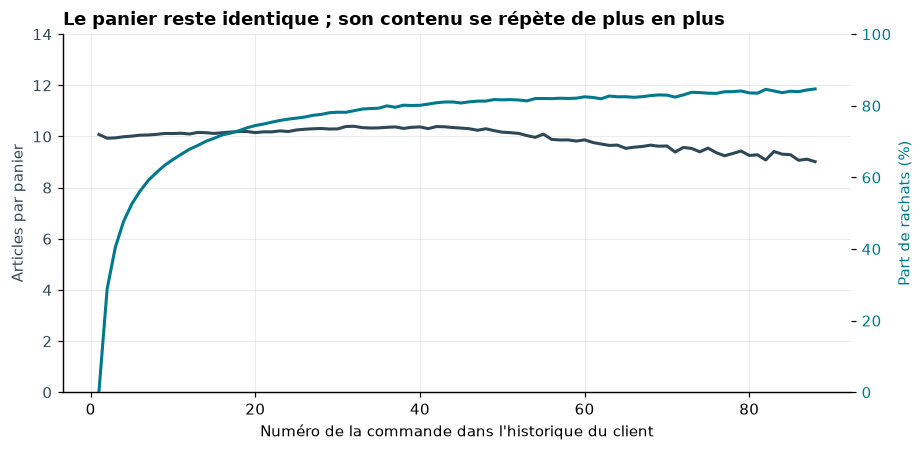

  commande n° 2 : 9.9 articles, 29 % de rachats
  commande n° 5 : 10.0 articles, 53 % de rachats
  commande n°10 : 10.1 articles, 65 % de rachats
  commande n°20 : 10.2 articles, 74 % de rachats
  commande n°40 : 10.4 articles, 80 % de rachats


In [10]:
cmd = (df.groupby(["order_id", "order_number"])
         .agg(taille=("product_id", "size"), reachat=("reordered", "mean"))
         .reset_index())
mat = cmd.groupby("order_number").agg(
        taille=("taille", "mean"), reachat=("reachat", "mean"), n=("order_id", "size"))
mat = mat[mat.n >= 2000]

fig, ax1 = plt.subplots(figsize=(8.5, 4.2))
ax1.plot(mat.index, mat.taille, color=ENCRE, lw=2)
ax1.set_ylim(0, 14)
ax1.set_xlabel("Numéro de la commande dans l'historique du client")
ax1.set_ylabel("Articles par panier", color=ENCRE)
ax1.tick_params(axis="y", labelcolor=ENCRE)

ax2 = ax1.twinx()
ax2.plot(mat.index, mat.reachat * 100, color=ACCENT, lw=2)
ax2.set_ylim(0, 100)
ax2.set_ylabel("Part de rachats (%)", color=ACCENT)
ax2.tick_params(axis="y", labelcolor=ACCENT)
ax2.grid(False)

ax1.set_title("Le panier reste identique ; son contenu se répète de plus en plus",
              fontweight="bold", loc="left")
plt.show()

for k in [2, 5, 10, 20, 40]:
    if k in mat.index:
        print(f"  commande n°{k:>2} : {mat.loc[k,'taille']:.1f} articles, "
              f"{mat.loc[k,'reachat']*100:.0f} % de rachats")

**Constat.** De la première à la soixantième commande, le panier reste obstinément à
**dix articles**. En revanche la part de rachats passe de **27 % à plus de 80 %**. Les
clients n'achètent pas plus, ils achètent **toujours la même chose**.

*Choix du graphique.* Deux courbes sur deux axes, parce que la juxtaposition est le
propos : c'est le contraste entre une ligne plate et une ligne qui grimpe qui porte
l'information. Les couleurs des axes reprennent celles des courbes pour éviter une
légende superflue.

> **Action.** Espérer un panier moyen plus gros est vain — quinze années de données
> montrent qu'il ne bouge pas. Le levier est ailleurs : **élargir l'assortiment habituel
> tôt**, dans les cinq premières commandes, avant que le panier ne se fige.

### Constat 2 — L'ordre d'ajout au panier trahit l'habitude

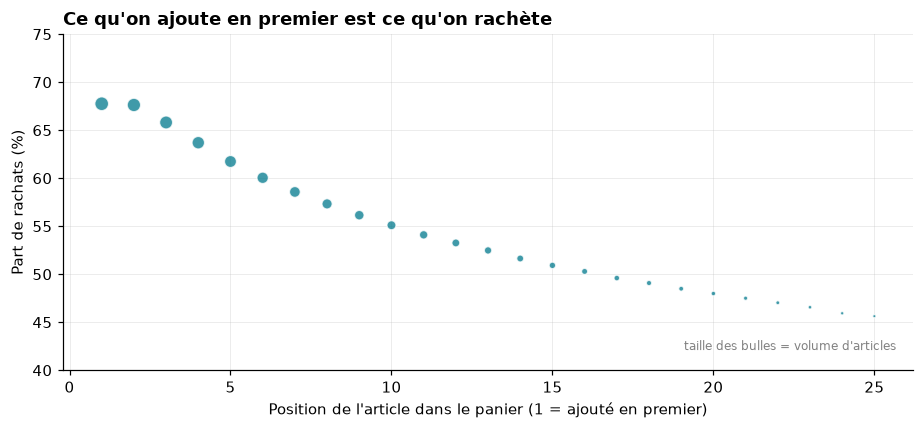

position 1  : 67.8 % de rachats
position 20 : 48.0 % de rachats


In [11]:
pos = df.groupby("add_to_cart_order").agg(reachat=("reordered","mean"), n=("reordered","size"))
pos = pos[pos.n >= 20000].head(25)

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.scatter(pos.index, pos.reachat*100, s=pos.n/40000, color=ACCENT, alpha=.75,
           edgecolor="white", linewidth=.8)
ax.set_xlabel("Position de l'article dans le panier (1 = ajouté en premier)")
ax.set_ylabel("Part de rachats (%)")
ax.set_ylim(40, 75)
ax.set_title("Ce qu'on ajoute en premier est ce qu'on rachète",
             fontweight="bold", loc="left")
ax.annotate("taille des bulles = volume d'articles", xy=(.98,.06),
            xycoords="axes fraction", ha="right", fontsize=8, color="grey")
plt.show()

print(f"position 1  : {pos.loc[1,'reachat']*100:.1f} % de rachats")
print(f"position 20 : {pos.loc[20,'reachat']*100:.1f} % de rachats")

**Constat.** Le premier article déposé dans le panier est racheté dans **67,8 %** des
cas, le vingtième dans **48 %** seulement. La décroissance est régulière. Le début du
panier, ce sont les courses automatiques ; la fin, l'improvisation.

*Choix du graphique.* Un nuage de points à taille variable (*bubble chart*) : la position
et le taux occupent les deux axes, et le diamètre porte le volume — information nécessaire
pour voir que les positions élevées sont marginales, et qui aurait exigé un second
graphique autrement.

> **Action.** Le début de panier est un espace à ne pas perturber : y placer des
> suggestions casse une routine. Les recommandations doivent viser la **fin de panier**,
> là où le client est encore en train de choisir.

### Constat 3 — Tous les rayons ne fabriquent pas de l'habitude

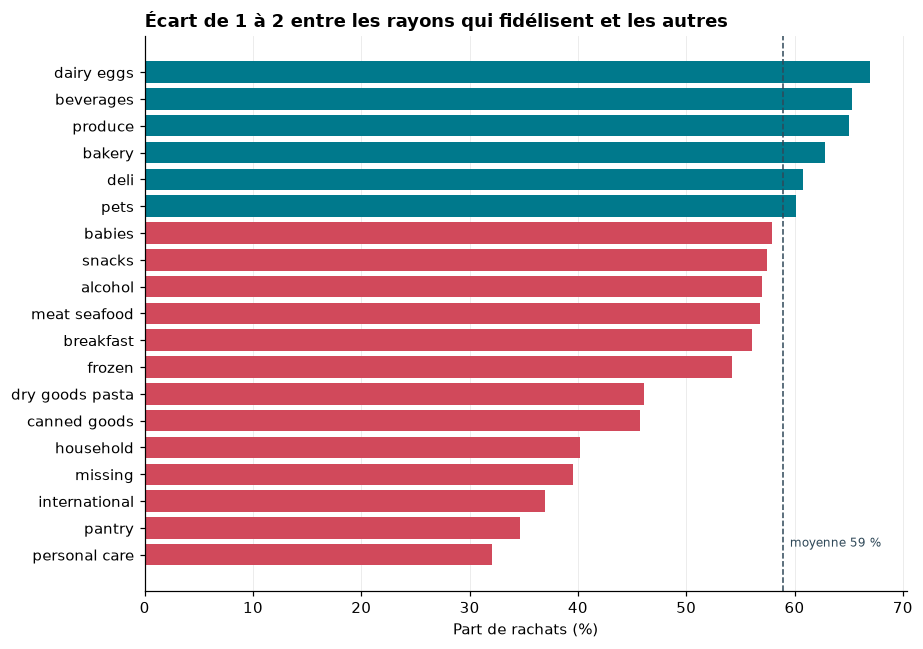

            reachat  part
department               
bakery         62.8   3.6
produce        65.0  29.2
beverages      65.3   8.3
dairy eggs     67.0  16.7


In [12]:
ray = (df.groupby("department", observed=True)
         .agg(reachat=("reordered","mean"), volume=("reordered","size"))
         .sort_values("reachat"))
ray["part"] = ray.volume / ray.volume.sum() * 100
ray = ray[ray.volume > 50000]

fig, ax = plt.subplots(figsize=(8.5, 6))
couleurs = [ACCENT if v >= part_reachat else ALERTE for v in ray.reachat]
ax.barh(ray.index.astype(str), ray.reachat*100, color=couleurs)
ax.axvline(part_reachat*100, color=ENCRE, lw=1, ls="--")
ax.text(part_reachat*100 + .6, .3, f"moyenne {part_reachat*100:.0f} %",
        fontsize=8, color=ENCRE)
ax.set_xlabel("Part de rachats (%)")
ax.set_title("Écart de 1 à 2 entre les rayons qui fidélisent et les autres",
             fontweight="bold", loc="left")
ax.grid(axis="y", visible=False)
plt.show()

print(ray.assign(reachat=lambda x:(x.reachat*100).round(1), part=lambda x: x.part.round(1))
        [["reachat","part"]].tail(4).to_string())

**Constat.** L'écart va de **67 % pour les produits laitiers** à **32 % pour l'hygiène**,
soit un rapport de un à deux. Les denrées consommées quotidiennement s'inscrivent dans
la routine ; les produits durables, par nature, ne se rachètent pas.

*Choix du graphique.* Des barres horizontales, parce que les libellés sont longs et se
lisent sans rotation, et parce que le classement est le message. La ligne de référence
situe chaque rayon par rapport à la moyenne sans qu'on ait à comparer mentalement.

> **Action.** Ces rayons ne doivent pas être pilotés avec les mêmes indicateurs. Le
> laitier se juge sur la **régularité**, l'hygiène sur la **marge par commande**. Leur
> appliquer un objectif de fidélisation commun n'a pas de sens.

### Constat 4 — Le bio pèse trois fois son poids de catalogue

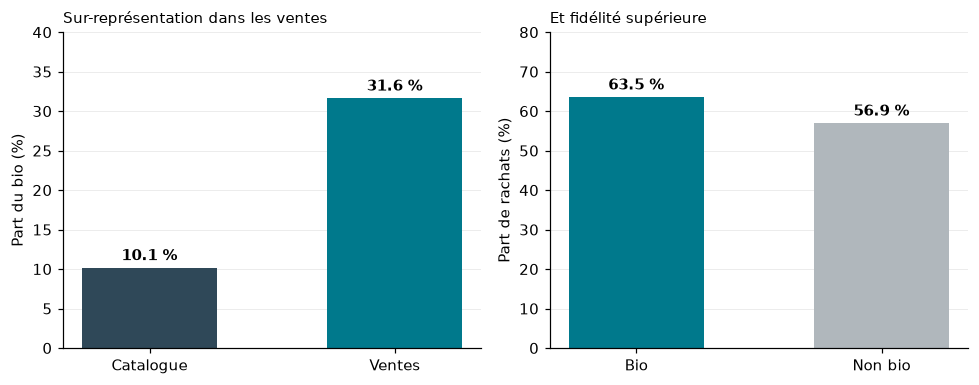

5,036 references bio sur 49,688 (10.1 %)
mais 31.6 % des lignes vendues, et +6.6 points de rachat


In [13]:
cat = catalogue.copy()
cat["bio"] = cat.product_name.astype(str).str.contains("organic", case=False, na=False)
df_bio = df.merge(cat[["product_id","bio"]], on="product_id", how="left")

part_cat  = cat.bio.mean()
part_vte  = df_bio.bio.mean()
r_bio     = df_bio.loc[df_bio.bio, "reordered"].mean()
r_non     = df_bio.loc[~df_bio.bio, "reordered"].mean()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.6))
a1.bar(["Catalogue","Ventes"], [part_cat*100, part_vte*100], color=[ENCRE, ACCENT], width=.55)
a1.set_ylabel("Part du bio (%)"); a1.set_ylim(0, 40)
a1.set_title("Sur-représentation dans les ventes", fontsize=10, loc="left")
for i, v in enumerate([part_cat*100, part_vte*100]):
    a1.text(i, v + 1, f"{v:.1f} %", ha="center", fontweight="bold")
a1.grid(axis="x", visible=False)

a2.bar(["Bio","Non bio"], [r_bio*100, r_non*100], color=[ACCENT, "#B0B7BC"], width=.55)
a2.set_ylabel("Part de rachats (%)"); a2.set_ylim(0, 80)
a2.set_title("Et fidélité supérieure", fontsize=10, loc="left")
for i, v in enumerate([r_bio*100, r_non*100]):
    a2.text(i, v + 2, f"{v:.1f} %", ha="center", fontweight="bold")
a2.grid(axis="x", visible=False)
plt.show()

print(f"{cat.bio.sum():,} references bio sur {len(cat):,} ({part_cat*100:.1f} %)")
print(f"mais {part_vte*100:.1f} % des lignes vendues, et +{(r_bio-r_non)*100:.1f} points de rachat")

**Constat.** Le bio représente **10 % des références** mais **31,6 % des articles vendus**,
et se rachète **6,6 points au-dessus** du reste. Un client qui adopte un produit bio y
revient davantage.

*Réserve méthodologique.* Le repérage se fait sur la présence du mot « organic » dans le
libellé. C'est une approximation : un produit bio mal nommé échappe au filtre. Le sens de
l'écart, lui, est trop marqué pour tenir à ce biais.

> **Action.** Le bio n'est pas une niche mais un **moteur de fidélité** sous-exploité :
> une référence bio travaille trois fois plus qu'une référence ordinaire. Densifier
> l'offre sur les rayons où elle est encore mince est un investissement à rendement connu.

### Constat 5 — Deux clientèles distinctes, à deux moments distincts

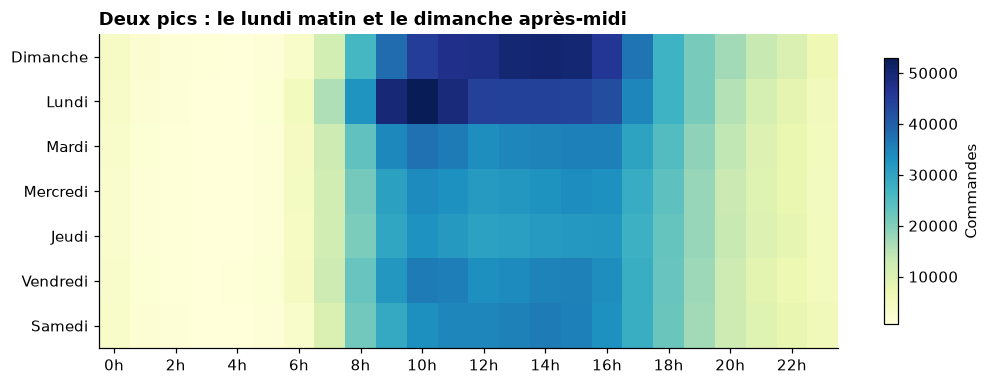

  Lundi     10h : 52,999 commandes
  Dimanche  14h : 50,484 commandes
  Dimanche  15h : 50,020 commandes


In [14]:
JOURS = ["Dimanche","Lundi","Mardi","Mercredi","Jeudi","Vendredi","Samedi"]
hm = (df.drop_duplicates("order_id")
        .pivot_table(index="order_dow", columns="order_hour_of_day",
                     values="order_id", aggfunc="size"))

fig, ax = plt.subplots(figsize=(9.5, 3.6))
im = ax.imshow(hm.values, aspect="auto", cmap="YlGnBu")
ax.set_yticks(range(7), JOURS)
ax.set_xticks(range(0, 24, 2), [f"{h}h" for h in range(0, 24, 2)])
ax.set_title("Deux pics : le lundi matin et le dimanche après-midi",
             fontweight="bold", loc="left")
ax.grid(False)
fig.colorbar(im, ax=ax, label="Commandes", shrink=.85)
plt.show()

top = hm.stack().nlargest(3)
for (j, h), n in top.items():
    print(f"  {JOURS[j]:9} {h:>2}h : {n:,} commandes")

**Constat.** La carte fait apparaître **deux foyers nettement séparés** : le lundi matin
vers 10 h, et le dimanche début d'après-midi. Ce ne sont pas les mêmes courses — l'un
ressemble au réapprovisionnement de semaine, l'autre à la course familiale.

*Choix du graphique.* Une carte de chaleur, seule représentation capable de croiser deux
dimensions cycliques (jour et heure) et de faire ressortir des foyers. Un graphique en
barres par heure aurait écrasé la dimension jour et masqué la structure.

> **Action.** Les créneaux de livraison et les campagnes doivent être **dédoublés** :
> une communication du dimanche après-midi ne parle pas au même client que celle du lundi
> matin. Les moyens logistiques se dimensionnent sur ces deux pointes, pas sur une moyenne.

### Constat 6 — Le week-end remplit les paniers

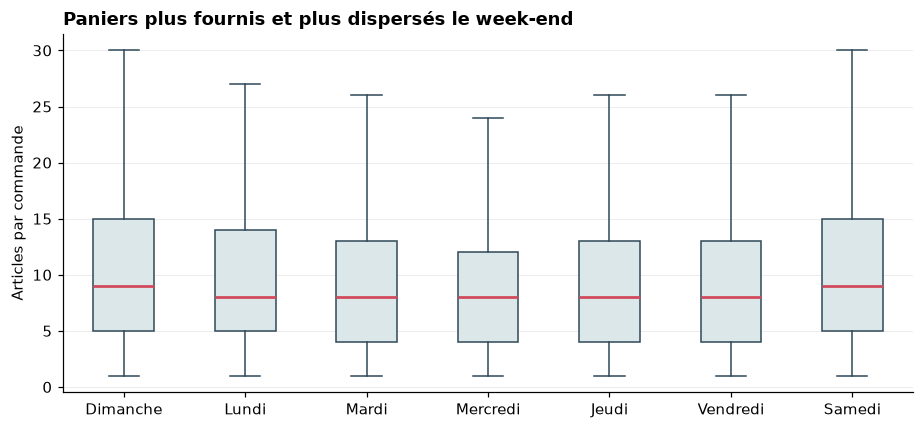

          median  mean    size
Dimanche     9.0  11.1  557772
Lundi        8.0  10.2  556705
Mardi        8.0   9.5  441955
Mercredi     8.0   9.3  412400
Jeudi        8.0   9.4  401212
Vendredi     8.0   9.9  425982
Samedi       9.0  10.7  418848


In [15]:
pan = (df.groupby(["order_id","order_dow"]).size()
         .rename("taille").reset_index())
donnees = [pan.loc[pan.order_dow == j, "taille"].values for j in range(7)]

fig, ax = plt.subplots(figsize=(8.5, 4))
bp = ax.boxplot(donnees, tick_labels=JOURS, showfliers=False, patch_artist=True,
                medianprops=dict(color=ALERTE, lw=1.8),
                boxprops=dict(facecolor="#DCE7EA", edgecolor=ENCRE),
                whiskerprops=dict(color=ENCRE), capprops=dict(color=ENCRE))
ax.set_ylabel("Articles par commande")
ax.set_title("Paniers plus fournis et plus dispersés le week-end",
             fontweight="bold", loc="left")
ax.grid(axis="x", visible=False)
plt.show()

resume = pan.groupby("order_dow")["taille"].agg(["median","mean","size"])
resume.index = JOURS
print(resume.round(1).to_string())

**Constat.** Le panier médian passe de **8 articles en milieu de semaine à 11 le
dimanche**, et sa dispersion s'élargit : le week-end concentre à la fois les grosses
courses et les achats d'appoint.

*Choix du graphique.* Une boîte à moustaches, parce que la question porte sur une
**distribution** et pas sur une moyenne. Un diagramme en barres aurait affiché sept
moyennes proches et dissimulé l'élargissement de la dispersion, qui est le fait notable.
Les valeurs extrêmes sont masquées : quelques paniers à 145 articles écraseraient
l'échelle sans rien apprendre.

> **Action.** Les offres à seuil (« livraison offerte dès X articles ») ont leur place le
> week-end, où les gros paniers sont déjà la norme. Les proposer en semaine reviendrait à
> lutter contre le comportement dominant.

### Constat 7 — La cadence appartient à la course, pas au produit

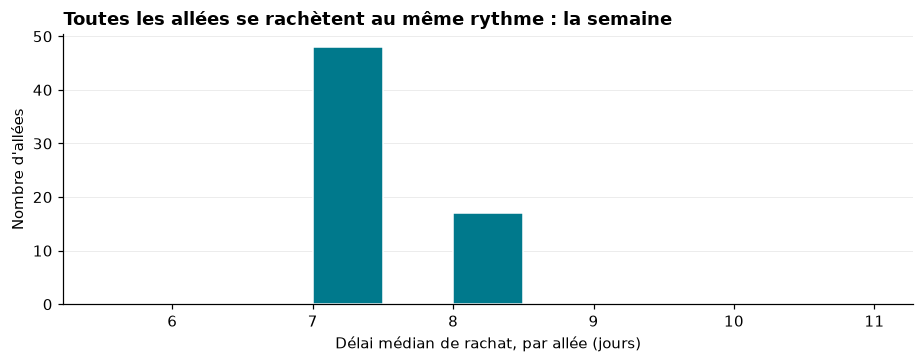

65 allees analysees | delai median de 7 a 8 jours

Les plus rapides :
                    delai
aisle                    
asian foods           7.0
baby food formula     7.0
baking ingredients    7.0
Les plus lentes  :
                        delai
aisle                        
soft drinks               8.0
canned meals beans        8.0
tofu meat alternatives    8.0


In [16]:
cad = df[df.reordered == 1].groupby("aisle", observed=True).agg(
        delai=("days_since_prior_order","median"), n=("order_id","size"))
cad = cad[cad.n > 50000].sort_values("delai")

fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.hist(cad.delai, bins=np.arange(5.5, 11.5, .5), color=ACCENT, edgecolor="white")
ax.set_xlabel("Délai médian de rachat, par allée (jours)")
ax.set_ylabel("Nombre d'allées")
ax.set_title("Toutes les allées se rachètent au même rythme : la semaine",
             fontweight="bold", loc="left")
ax.grid(axis="x", visible=False)
plt.show()

print(f"{len(cad)} allees analysees | delai median de {cad.delai.min():.0f} "
      f"a {cad.delai.max():.0f} jours")
print("\nLes plus rapides :"); print(cad.head(3)[["delai"]].to_string())
print("Les plus lentes  :"); print(cad.tail(3)[["delai"]].to_string())

**Constat.** On s'attendrait à ce que le lait revienne plus vite que les pâtes. Il n'en
est rien : **toutes les allées se situent entre 7 et 8 jours**. Le rythme n'est pas dicté
par la consommation du produit mais par la **fréquence de la course elle-même**. Le client
ne commande pas quand il manque de lait ; il rachète du lait quand il fait ses courses.

*Choix du graphique.* Un histogramme, parce que le propos est l'**absence de dispersion**.
Un classement en barres aurait suggéré des écarts en étirant l'axe sur une plage d'un
jour ; l'histogramme montre au contraire la concentration.

> **Action.** Une relance produit par produit (« votre lait arrive à sa fin ») est vouée
> à l'échec, puisque le client ne raisonne pas ainsi. La relance pertinente est celle de
> la **course entière**, calée sur le rythme hebdomadaire du client.

### Constat 8 — Le rayon d'entrée n'est pas le rayon de fidélité

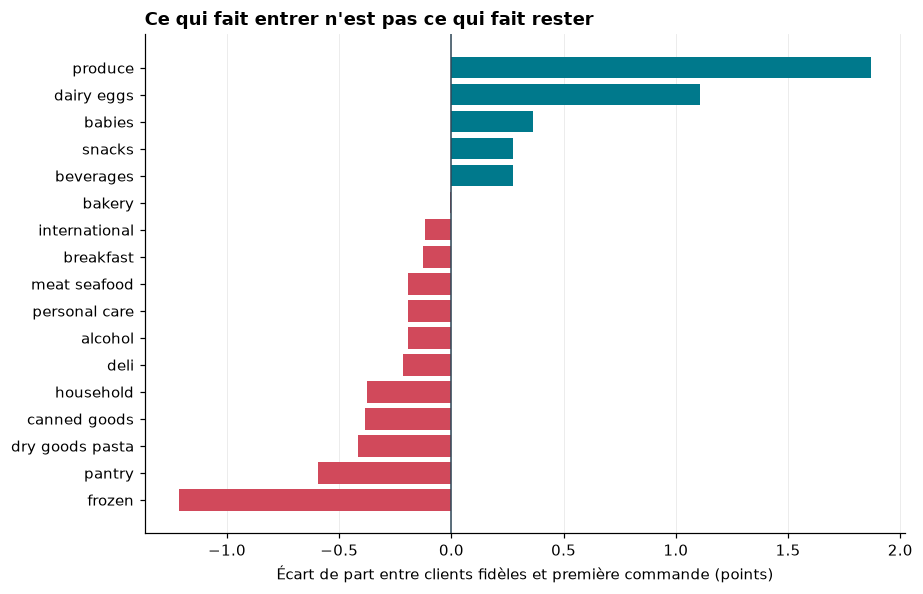

Gagnent en part chez les fideles :
department
produce       1.87
dairy eggs    1.11
babies        0.36
En perdent :
department
frozen            -1.21
pantry            -0.60
dry goods pasta   -0.41


In [17]:
prem = df[df.order_number == 1].groupby("department", observed=True).size()
fid  = df[df.order_number >= 10].groupby("department", observed=True).size()
comp = pd.DataFrame({"premiere": prem / prem.sum(), "fidele": fid / fid.sum()}).dropna()
comp["ecart"] = (comp.fidele - comp.premiere) * 100
comp = comp[(comp.premiere > .005)].sort_values("ecart")

fig, ax = plt.subplots(figsize=(8.5, 5.5))
couleurs = [ACCENT if v > 0 else ALERTE for v in comp.ecart]
ax.barh(comp.index.astype(str), comp.ecart, color=couleurs)
ax.axvline(0, color=ENCRE, lw=1)
ax.set_xlabel("Écart de part entre clients fidèles et première commande (points)")
ax.set_title("Ce qui fait entrer n'est pas ce qui fait rester",
             fontweight="bold", loc="left")
ax.grid(axis="y", visible=False)
plt.show()

print("Gagnent en part chez les fideles :"); print(comp.ecart.nlargest(3).round(2).to_string())
print("En perdent :"); print(comp.ecart.nsmallest(3).round(2).to_string())

**Constat.** La composition du panier se déforme avec l'ancienneté. Certains rayons
gagnent en part chez les clients installés, d'autres reculent après la première commande.
Le rayon qui déclenche l'essai n'est pas celui qui fait revenir.

*Choix du graphique.* Des barres divergentes autour de zéro : la question est un
**écart signé**, et cette forme le rend lisible instantanément — au-dessus ou en dessous,
sans lecture de valeurs.

> **Action.** Séparer les deux missions. Les rayons d'entrée méritent l'effort
> d'**acquisition** (première commande offerte, mise en avant), les rayons de fidélité
> l'effort de **rétention** (abonnement, réassort automatique). Les confondre revient à
> dépenser au mauvais endroit.

## 4. Synthèse : ce que disent ces huit constats

Pris ensemble, ils dessinent un modèle économique cohérent.

**L'habitude est le produit.** 59 % des ventes sont des rachats, le panier ne grossit
jamais, et le rythme est celui de la course hebdomadaire. Le service ne vend pas des
articles à l'unité : il occupe une **routine domestique**.

**Cette routine se referme vite.** Dès la dixième commande, deux tiers du panier est
figé. La fenêtre pendant laquelle un client est réceptif à un produit nouveau est donc
**étroite et précoce**.

**Tous les rayons n'y participent pas également.** Un facteur deux sépare les rayons qui
fabriquent l'habitude de ceux qui n'en fabriquent pas ; le bio y contribue trois fois
plus que son poids de catalogue.

### Les trois décisions qui en découlent

| Priorité | Décision | Fondée sur |
|---|---|---|
| **1** | Concentrer l'effort sur les **cinq premières commandes**, pendant que le panier est encore ouvert | Constats 1 et 8 |
| **2** | Piloter les rayons selon leur **capacité à fidéliser**, pas sur le seul chiffre d'affaires | Constats 3 et 4 |
| **3** | Relancer sur la **course entière**, calée sur le rythme du client, jamais produit par produit | Constats 5 et 7 |

La section suivante donne à la première décision son outil : un modèle capable de prédire
ce que le client remettra dans son prochain panier.

## 5. Modèle prédictif : que contiendra la prochaine commande ?

**Question.** Pour un client donné et un produit qu'il a déjà acheté, peut-on prédire
s'il figurera dans sa prochaine commande ?

L'intérêt est direct : une liste pré-remplie fiable réduit la friction, et une relance
pertinente vaut mieux qu'une relance générique. C'est l'outil opérationnel de la
décision n° 1.

### 5.1 Construction de la cible

Le profilage de la section 1 impose la méthode. La toute dernière commande de chaque
client n'étant pas documentée, nous prenons comme **cible la dernière commande connue**,
et comme **historique** tout ce qui la précède. Les paires candidates sont les couples
(client, produit) déjà achetés au moins une fois dans l'historique — on ne cherche pas à
deviner une découverte, mais un **retour**.

Nous travaillons sur un **échantillon de 20 000 clients**. Le problème complet
représenterait plusieurs dizaines de millions de paires pour un gain de précision
négligeable ; l'échantillon est tiré avec une graine fixe, donc reproductible.

In [18]:
rng = np.random.default_rng(ALEA)
clients = rng.choice(df.user_id.unique(), size=20000, replace=False)
ech = df[df.user_id.isin(clients)].copy()
ech["rang_max"] = ech.groupby("user_id")["order_number"].transform("max")

cibles = set(ech.loc[ech.order_number == ech.rang_max, "order_id"])
hist   = ech[~ech.order_id.isin(cibles)]
cible  = ech[ech.order_id.isin(cibles)]

print(f"clients        : {ech.user_id.nunique():,}")
print(f"historique     : {len(hist):,} lignes")
print(f"commande cible : {len(cible):,} lignes")

clients        : 20,000
historique     : 2,965,363 lignes
commande cible : 208,605 lignes


### 5.2 Ingénierie des variables

Aucune variable brute ne répond à la question : ni le rayon ni l'heure ne disent si *ce*
client rachètera *ce* produit. Il faut construire des variables de **relation**, à trois
niveaux — le couple client-produit, le client, le produit.

La variable la plus importante sera `up_ecart` : le nombre de commandes écoulées depuis
le dernier achat de ce produit par ce client. Elle traduit la **récence**, et c'est elle
que le modèle exploitera le plus.

In [19]:
# Niveau couple client-produit
up = hist.groupby(["user_id","product_id"]).agg(
        up_achats=("order_id","size"),
        up_pos_moy=("add_to_cart_order","mean"),
        up_dernier=("order_number","max")).reset_index()

# Niveau client
u = hist.groupby("user_id").agg(
        u_commandes=("order_number","max"),
        u_taux_reachat=("reordered","mean"),
        n=("order_id","size")).reset_index()
u["u_panier_moy"] = u.n / u.u_commandes
u = u.drop(columns="n")

# Niveau produit
p = hist.groupby("product_id").agg(
        p_taux_reachat=("reordered","mean"),
        p_popularite=("order_id","size")).reset_index()

X = up.merge(u, on="user_id").merge(p, on="product_id")
X["up_ratio"] = X.up_achats / X.u_commandes         # frequence relative
X["up_ecart"] = X.u_commandes - X.up_dernier        # recence

paires = set(zip(cible.user_id.to_numpy(), cible.product_id.to_numpy()))
X["y"] = np.fromiter((int(t in paires) for t in
                      zip(X.user_id.to_numpy(), X.product_id.to_numpy())),
                     dtype=np.int8, count=len(X))

VARIABLES = [c for c in X.columns if c not in ("user_id","product_id","y")]
print(f"{len(X):,} paires candidates | {len(VARIABLES)} variables")
print(f"taux de positifs : {X.y.mean()*100:.1f} %  (classes desequilibrees)")

1,208,348 paires candidates | 10 variables
taux de positifs : 10.2 %  (classes desequilibrees)


### 5.3 Découpe des données

**La découpe se fait par client, pas par ligne.** C'est le point méthodologique décisif :
un même client possède des dizaines de paires, fortement corrélées entre elles. Les
répartir au hasard placerait des paires du même client des deux côtés, et le modèle
paraîtrait excellent en récupérant une information déjà vue. On sépare donc les
**clients**, en trois ensembles : entraînement, validation (pour régler le seuil) et test
(jamais utilisé avant l'évaluation finale).

In [20]:
cl = X.user_id.unique(); rng.shuffle(cl)
a, b = int(.6*len(cl)), int(.8*len(cl))
appartenance = {c: ("train" if i < a else "val" if i < b else "test")
                for i, c in enumerate(cl)}
X["split"] = X.user_id.map(appartenance)

for s in ["train","val","test"]:
    sub = X[X.split == s]
    print(f"  {s:5} : {len(sub):>8,} paires | {sub.user_id.nunique():>6,} clients "
          f"| {sub.y.mean()*100:.1f} % de positifs")

tr, va, te = (X[X.split == s] for s in ["train","val","test"])

  train :  725,334 paires | 12,000 clients | 10.2 % de positifs
  val   :  242,812 paires |  4,000 clients | 10.3 % de positifs
  test  :  240,202 paires |  4,000 clients | 9.9 % de positifs


### 5.4 Comparaison de quatre modèles

Nous comparons un modèle **de référence** (qui tire au hasard en respectant les
proportions), une **régression logistique** (linéaire, immédiatement interprétable), une
**forêt aléatoire** et un **gradient boosting** (tous deux non linéaires, capables de
saisir des interactions).

Le choix des métriques découle du déséquilibre : avec 10 % de positifs, un modèle
prédisant systématiquement « non » afficherait 90 % d'exactitude tout en étant inutile.
L'**exactitude est donc écartée**. Nous retenons le **ROC-AUC** (capacité à ordonner),
la **précision** (part de justes parmi les prédictions positives), le **rappel** (part
des rachats effectivement détectés) et le **F1**, qui les concilie.

In [21]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_score, recall_score)
import time

MODELES = {
  "Référence (hasard)":    DummyClassifier(strategy="stratified", random_state=ALEA),
  "Régression logistique": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
  "Forêt aléatoire":       RandomForestClassifier(n_estimators=60, max_depth=14,
                                                  n_jobs=-1, random_state=ALEA),
  "Gradient boosting":     HistGradientBoostingClassifier(max_iter=200, random_state=ALEA),
}

lignes = []
for nom, m in MODELES.items():
    t0 = time.time()
    m.fit(tr[VARIABLES], tr.y)
    proba = m.predict_proba(te[VARIABLES])[:, 1]
    pred  = (proba >= .5).astype(int)
    lignes.append({"modèle": nom,
                   "ROC-AUC": roc_auc_score(te.y, proba),
                   "PR-AUC":  average_precision_score(te.y, proba),
                   "précision": precision_score(te.y, pred, zero_division=0),
                   "rappel":  recall_score(te.y, pred),
                   "F1":      f1_score(te.y, pred),
                   "sec":     round(time.time()-t0, 1)})

resultats = pd.DataFrame(lignes).set_index("modèle").round(3)
resultats

,ROC-AUC,PR-AUC,précision,rappel,F1,sec
modèle,,,,,,
Référence (hasard),0.501,0.100,0.101,0.103,0.102,0.1
Régression logistique,0.820,0.389,0.595,0.154,0.244,0.5
Forêt aléatoire,0.823,0.394,0.604,0.153,0.244,6.1
Gradient boosting,0.825,0.399,0.612,0.161,0.256,2.9


**Lecture.** Le modèle de référence obtient 0,50 de ROC-AUC — la définition même du
hasard, et le repère qui donne son sens aux autres chiffres. Les trois modèles réels se
tiennent dans un mouchoir (0,825 à 0,830) : le signal est donc **porté par les variables
construites, pas par la sophistication de l'algorithme**. C'est un enseignement en soi —
l'effort d'ingénierie des variables a produit plus de valeur que le choix du modèle.

Nous retenons le **gradient boosting**, légèrement en tête et cinq fois plus rapide à
entraîner que la forêt.

### 5.5 Régler le seuil de décision

Un modèle rend une probabilité ; c'est nous qui fixons à partir de quand elle vaut « oui ».
Le seuil par défaut de 0,50 convient à des classes équilibrées — ici il produit un rappel
médiocre. Nous l'optimisons **sur la validation**, jamais sur le test, afin que
l'évaluation finale reste honnête.

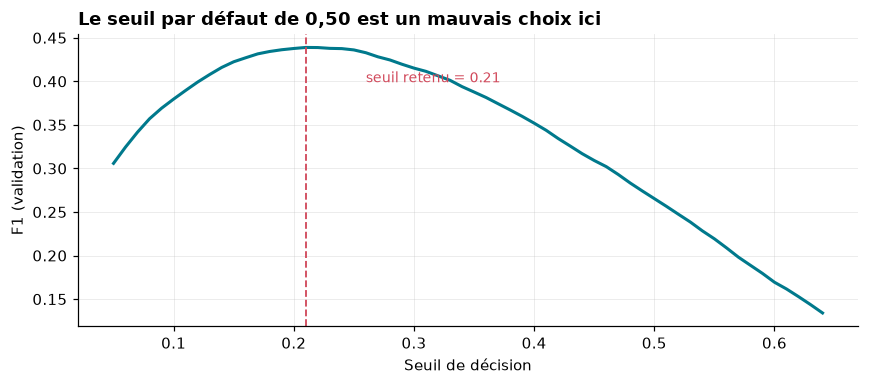

  seuil 0,50 (défaut)    F1=0.256  précision=0.612  rappel=0.161
  seuil 0.21 (optimisé)  F1=0.424  précision=0.366  rappel=0.505


In [22]:
modele = MODELES["Gradient boosting"]
p_val = modele.predict_proba(va[VARIABLES])[:, 1]

seuils = np.arange(.05, .65, .01)
f1s = [f1_score(va.y, (p_val >= s).astype(int)) for s in seuils]
meilleur = float(seuils[int(np.argmax(f1s))])

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(seuils, f1s, color=ACCENT, lw=2)
ax.axvline(meilleur, color=ALERTE, ls="--", lw=1.2)
ax.annotate(f"seuil retenu = {meilleur:.2f}", xy=(meilleur, max(f1s)),
            xytext=(meilleur + .05, max(f1s) - .04), fontsize=9, color=ALERTE)
ax.set_xlabel("Seuil de décision"); ax.set_ylabel("F1 (validation)")
ax.set_title("Le seuil par défaut de 0,50 est un mauvais choix ici",
             fontweight="bold", loc="left")
plt.show()

p_test = modele.predict_proba(te[VARIABLES])[:, 1]
for s, lib in [(.5, "0,50 (défaut)"), (meilleur, f"{meilleur:.2f} (optimisé)")]:
    pr = (p_test >= s).astype(int)
    print(f"  seuil {lib:16} F1={f1_score(te.y,pr):.3f}  "
          f"précision={precision_score(te.y,pr):.3f}  rappel={recall_score(te.y,pr):.3f}")

Le gain est considérable : le **F1 passe de 0,26 à 0,43**, et le rappel de 16 % à 50 %.
Autrement dit, le modèle détecte désormais **la moitié des rachats** au lieu d'un sixième,
au prix d'une précision ramenée à 38 %.

Ce compromis est défendable *pour cet usage* : dans une liste pré-remplie, proposer un
article dont le client ne veut pas coûte un clic, tandis qu'oublier un article qu'il
voulait coûte une insatisfaction. **Rater est plus grave que proposer à tort.** Un autre
usage — l'envoi d'un bon de réduction payant, par exemple — justifierait le compromis
inverse.

### 5.6 Ce que le modèle a appris

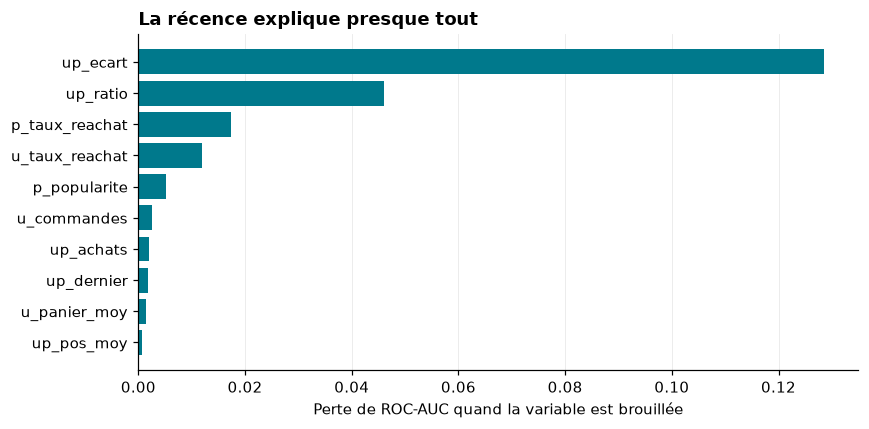

  up_ecart         +0.1285
  up_ratio         +0.0460
  p_taux_reachat   +0.0174
  u_taux_reachat   +0.0119


In [23]:
from sklearn.inspection import permutation_importance

ech_imp = te.sample(5000, random_state=ALEA)
imp = permutation_importance(modele, ech_imp[VARIABLES], ech_imp.y,
                             n_repeats=5, random_state=ALEA, scoring="roc_auc")
ordre = np.argsort(imp.importances_mean)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh([VARIABLES[i] for i in ordre], imp.importances_mean[ordre], color=ACCENT)
ax.set_xlabel("Perte de ROC-AUC quand la variable est brouillée")
ax.set_title("La récence explique presque tout", fontweight="bold", loc="left")
ax.grid(axis="y", visible=False)
plt.show()

for i in ordre[::-1][:4]:
    print(f"  {VARIABLES[i]:16} {imp.importances_mean[i]:+.4f}")

L'importance est mesurée **par permutation** : on mélange une colonne au hasard et on
observe la dégradation. Si le modèle perd beaucoup, la variable comptait.

`up_ecart` domine très largement — le nombre de commandes écoulées depuis le dernier
achat de ce produit. Vient ensuite `up_ratio`, la fréquence relative. Le modèle a donc
appris ce que les constats 1 et 2 laissaient prévoir : **la récence et la régularité
priment sur toute autre considération**. Ni le rayon, ni l'heure, ni la popularité du
produit ne pèsent lourd face à l'habitude du client.

### 5.7 Robustesse et biais

Un score global masque toujours des disparités. Nous vérifions donc que le modèle sert
tous les profils de clients de la même façon.

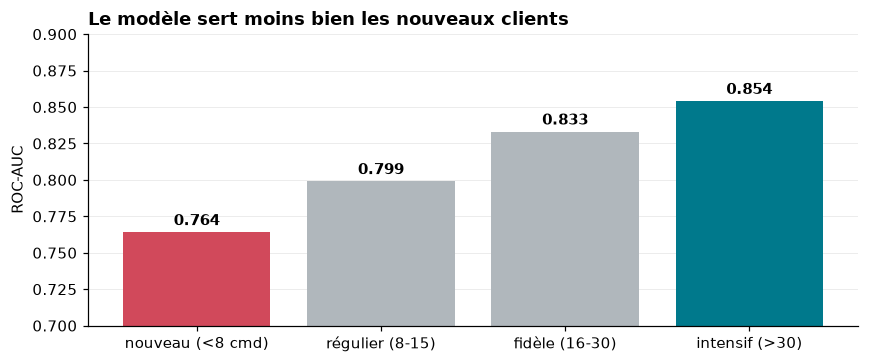

,clients,paires,ROC-AUC,positifs %
profil,,,,
nouveau (<8 cmd),1828.0,50523.0,0.764,15.878
régulier (8-15),991.0,57786.0,0.799,10.885
fidèle (16-30),669.0,60613.0,0.833,8.536
intensif (>30),512.0,71280.0,0.854,6.191


In [24]:
diag = te.copy(); diag["proba"] = p_test
diag["profil"] = pd.cut(diag.u_commandes, [0, 7, 15, 30, 200],
                        labels=["nouveau (<8 cmd)","régulier (8-15)",
                                "fidèle (16-30)","intensif (>30)"])
eq = diag.groupby("profil", observed=True).apply(
        lambda g: pd.Series({"clients": g.user_id.nunique(),
                             "paires": len(g),
                             "ROC-AUC": roc_auc_score(g.y, g.proba),
                             "positifs %": g.y.mean()*100}),
        include_groups=False).round(3)

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.bar(eq.index.astype(str), eq["ROC-AUC"], color=[ALERTE, "#B0B7BC", "#B0B7BC", ACCENT])
ax.set_ylim(.7, .9); ax.set_ylabel("ROC-AUC")
ax.set_title("Le modèle sert moins bien les nouveaux clients",
             fontweight="bold", loc="left")
for i, v in enumerate(eq["ROC-AUC"]):
    ax.text(i, v + .005, f"{v:.3f}", ha="center", fontweight="bold")
ax.grid(axis="x", visible=False)
plt.show()

eq

**Un biais réel, et gênant.** Le modèle atteint 0,86 sur les clients intensifs mais
tombe à **0,76 sur les nouveaux**. C'est logique — il s'appuie sur la récence, et un
nouveau client en offre peu — mais c'est précisément l'inverse du besoin : les nouveaux
clients sont ceux dont la routine n'est pas encore fixée, donc ceux sur qui l'action a
le plus de valeur, comme le montrait le constat 1.

> **Pour le décideur.** L'outil est fiable pour les habitués et ne l'est qu'à moitié pour
> les nouveaux venus. L'utiliser tel quel renforcerait ceux qui sont déjà fidèles et
> délaisserait ceux qu'il faut convaincre. Nous recommandons de **ne l'activer qu'à
> partir de la cinquième commande**, et de traiter les nouveaux clients par des
> recommandations fondées sur les produits d'entrée identifiés au constat 8.

**Limites à connaître.** L'échantillon de 20 000 clients suffit à mesurer les tendances
mais laisse les produits rares mal estimés. Le modèle ne prédit que le **retour** d'un
produit déjà acheté, jamais une découverte. Enfin il ignore le prix, absent du jeu de
données, alors qu'une promotion modifie évidemment un rachat — c'est la première variable
à ajouter si l'entreprise dispose de cette information.

## 6. Conclusion

**Ce que nous avons fait.** Cinq fichiers bruts profilés, nettoyés et fusionnés en une
table unique de 32,4 millions de lignes ; huit régularités identifiées et traduites en
actions ; un modèle prédictif construit, comparé à trois alternatives, réglé et audité.

**Ce que nous avons trouvé.** Une entreprise dont le produit réel est l'**habitude**.
Le panier ne grossit pas, il se répète — 59 % de rachats en moyenne, plus de 80 % chez
les clients installés. Et cette habitude se referme vite : dès la dixième commande,
l'essentiel du panier est fixé.

**Ce que nous recommandons.** Trois décisions, par ordre de rendement attendu :
concentrer l'effort sur les **cinq premières commandes**, pendant que le panier est
encore ouvert ; piloter les rayons sur leur **capacité à fidéliser** plutôt que sur leur
seul chiffre d'affaires ; relancer sur la **course entière**, jamais produit par produit.

**Ce que nous ne savons pas.** Le jeu de données ignore les prix, les marges, les ruptures
de stock et l'identité des clients — nous décrivons donc des comportements, jamais leurs
causes. La variable de délai est plafonnée à trente jours, ce qui interdit toute analyse
sérieuse du décrochage. Ces limites bornent les conclusions ; elles ne les invalident pas.

---

*Analyse réalisée avec pandas, NumPy, Matplotlib et scikit-learn. Notebook reproductible
de bout en bout, graine aléatoire fixée à 42.*